# Projeto Final de Modelos Avançados

**Objetivo do Projeto:**

O objetivo deste projeto é realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means, além de técnicas de exploração de dados, pré-processamento, implementação e avaliação de modelos.

Nossa variável alvo será a "Spending Score", uma nota de 1 a 100 que indica o comportamento de gastos do cliente.

In [38]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from plotly.subplots import make_subplots

## Análise Exploratória dos Dados
### Análise Exploratória - Geral


In [39]:
df = pd.read_csv("Mall_Customers.csv", delimiter=',')
df_original = df.copy()
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Como mostram os dados acima e abaixo, a base possui  colunas, como o esperado, e 200 linhas. O número de dados é pequeno, o que pode resultar em um modelo que não captura a diversidade e nuances do público. É possível que, pela amostra ser pequena, os dados estajam desbalanceados não por um comportamento natural da população estudada, mas pela forma com que os dados foram obtifos (exemplo: cadastro via uma promoção, obtidos em lojas específicas, cadastro do estacionamento, etc.)    

Os dados não possuem valores nulos, todos os tipos de dados estão adequados para sua variável e não há erros de digitação na variável categórica.
Há apenas uma variável categórica que pode ser posteriormente adaptada para análise numérica. 
A coluna com o ID do cliente não é do nosso interesse, então pode ser excluída.

In [40]:
df.drop(['CustomerID'],axis = 1, inplace=True)
df.head(2)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [41]:
print(f"Dimensões da base {df.shape}\n")
print("Verificando o tipo de dados das colunas:\n")
df.info()
print("\nVerificando valores nulos na base de dados:\n")
print(df.isnull().sum())
print("\nVerificando valores únicos nas colunas categóricas:\n")

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        print(df[coluna].unique())



Dimensões da base (200, 4)

Verificando o tipo de dados das colunas:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB

Verificando valores nulos na base de dados:

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Verificando valores únicos nas colunas categóricas:

['Male' 'Female']


Na análise estatística, as variáveis idade e nota de gasto apresentam o comportamento esperado. Já a variável de Receita Anual apresenta um valor máximo estranho, indicando que será necessário investigar por possíveis outliers ou por um  desbalancemanto.

Os valores de todas as variáveis são da mesma ordem de grandeza, dispensando a necessidade de padronização ou normalização.


In [42]:

print("\nVerificando estatísticas descritivas da base de dados:\n")
df.describe()


Verificando estatísticas descritivas da base de dados:



,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


### Análise Exploratória - Variáveis Categóricas


Na pré-avaliação da distribuição das variáveis em relação a variável categórica, a distribição apresenta um comportamento adequado, indicando que os dados estão saudáveis. 

Já é possível identificar que, apesar do grupo de gênero masculino ser proporcionalmente menor, sua receita e gastos é superior à do gênero feminino, comportamento esse encontrado também em outros espaços.

In [43]:

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        for categoria in df[coluna].unique():
            print(f"A coluna {coluna} possui {df[df[coluna] == categoria].shape[0]} registros na categoria {categoria}")


categoria = 'Gender'
contagem_categoria = df[categoria].value_counts(normalize=True).reset_index()
print(f"\n {contagem_categoria}\n")
for coluna in df:
    if coluna != categoria:
        
        media_categoria = df.groupby(categoria)[coluna].mean().reset_index().sort_values(by=coluna, ascending=False)
        desvio_padrao_categoria = df.groupby(categoria)[coluna].std().reset_index()
        print(f"\n{media_categoria}")



A coluna Gender possui 88 registros na categoria Male
A coluna Gender possui 112 registros na categoria Female

    Gender  proportion
0  Female        0.56
1    Male        0.44


   Gender        Age
1    Male  39.806818
0  Female  38.098214

   Gender  Annual Income (k$)
1    Male           62.227273
0  Female           59.250000

   Gender  Spending Score (1-100)
0  Female               51.526786
1    Male               48.511364


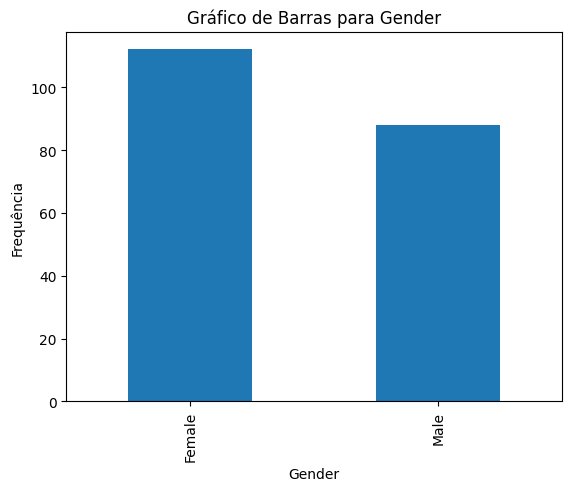

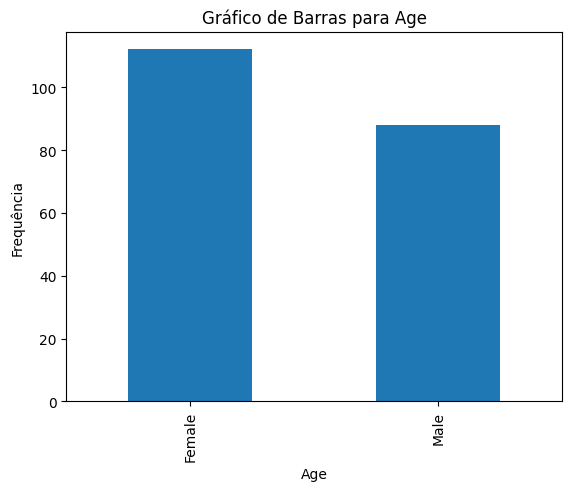

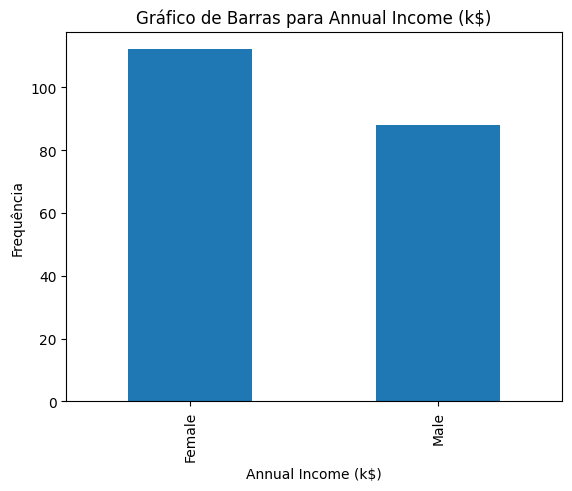

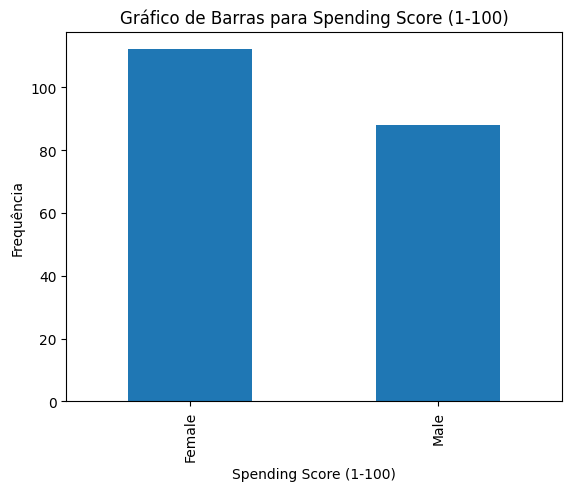

In [44]:
for campo in df:
    if df[campo].nunique() <= 10:  # Verifica se o campo é categórico
        contagem = df[campo].value_counts() 
    porcentagem = (contagem / contagem.sum()) * 100
    ax = contagem.plot(kind='bar')
    plt.title(f'Gráfico de Barras para {campo}')
    plt.xlabel(f'{campo}')
    plt.ylabel('Frequência')
    plt.show()


### Análise Exploratória - Possíveis Agrupamentos

Ao analisar os gráficos de distribuição das variáveis, o único agrupamento que se destaca, visualmente, é o da relação entre nota de gastos e receita anual. O gráfico mostra pelo menos 5 grupos. Esse valor pode ser usado para determinar o número de clusters do modelo.

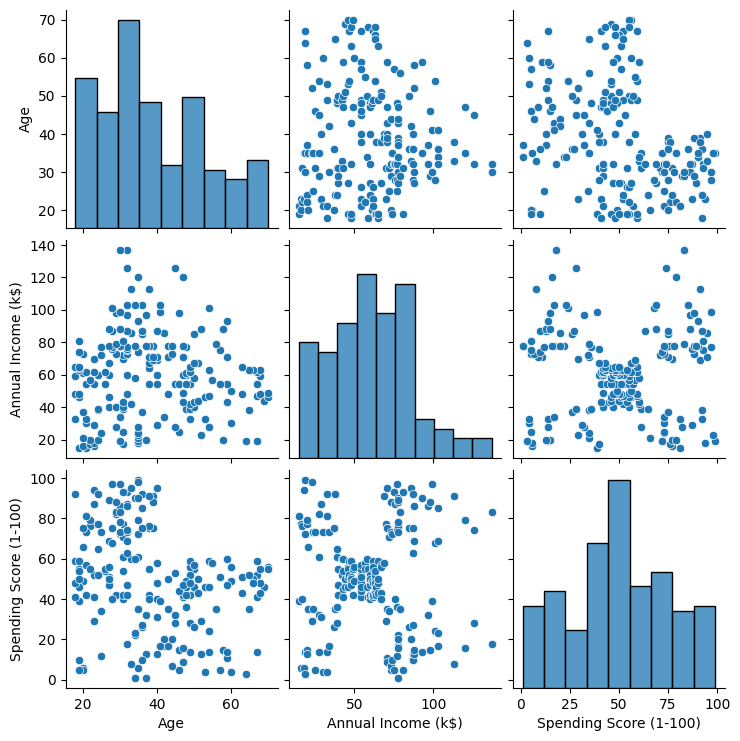

In [45]:
sns.pairplot(df)

## Tratamento de Dados

A partir da análise exploratória do item anterior, a única ação necessária é a transformação das variáveis categóricas em numéricas.

In [46]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
df.drop(['Gender'], axis = 1, inplace=True)
df.head(5)

,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [47]:
for campo in df.columns:
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
    fig.add_trace(
        px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
        row=1, col=1
    )
    fig.add_trace(
        px.box(df, y=campo).data[0],
        row=1, col=2
    )
    fig.update_layout(title_text=f'{campo}', showlegend=False)
    fig.show()
    

### Análise de Outliers

A anáslise estatística comentada anteriormente indicou a possibilidade de outlier na variável de receita anual (Annual Income). Para aprofundar esta análise, seguem abaixo a distribuição dos dados.

Como é possível ver pelos gráficos, o único ponto fora da curva é o valor máximo da coluna de receita anual. Por ser apena um, ele será excluído e passaremos para a próxima etapa.

In [48]:
df = df[df['Annual Income (k$)'] < 130 ]
print(df.shape)


(198, 4)


## Balanceamento - Distribuição da Variável Alvo

O gráfico abaixo mostra a distribuição dos dados por nota. O comportamento em escada mostra um padrão desbalanceado, com muitos dados para as notas mais baixas, e menos dados com o aumento da nota. Além disso, já é possível identificar possíveis grupos para nosso modelo de classificação, já que os dados parecem estar bem separados por grupos por nota.

Para corrigir esse desbalanceamento, irei aplicar o método Synthetic Minority Over-sampling Technique (SMOTE), em que são criados exemplos sintéticos da classe minoritária baseado na interpolação entre exemplos existentes da classe minoritária.

*Por esse motivo, sugiro que dois modelos sejam avaliados: um com os dados balanceados, outro como os dados originais.*

In [70]:
df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_encoded'],
      dtype='object')

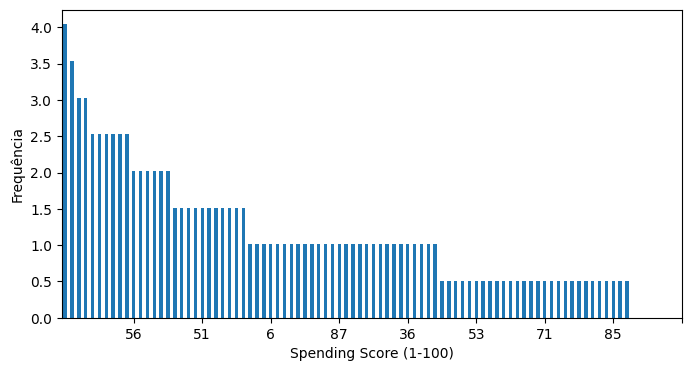

In [71]:
alvo_y = 'Spending Score (1-100)'
contagem_alvo = df[alvo_y].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo_y)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)

plt.show()

# Corrigir balanceamento, tenho que separar e fazer direitinho

In [72]:
from imblearn.over_sampling import SMOTE

x = df.drop('Spending Score (1-100)', axis = 1) 
y = df['Spending Score (1-100)']
smote = SMOTE(random_state=42)
xb, yb = smote.fit_resample(x,y)
train_balance = yb.value_counts()

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 2, n_samples = 2

## Implementação do Algoritmo K-Means

O número de clusters (k) escolhi foi 5, como visualmente indicado pelos gráficos de distribuição. Para melhor performance do modelo, optou-se por padronizar os dados.


In [62]:
from sklearn.preprocessing import StandardScaler
df_padrao = df.copy()
colunas_padronizar = df.columns
scaler = StandardScaler()
df_padrao[colunas_padronizar] = scaler.fit_transform(df_padrao[colunas_padronizar])

In [63]:
kmeans_perfil = KMeans (n_clusters=5, n_init=10, random_state=42)
kmeans_perfil.fit(df_padrao)
centroides_padrao = kmeans_perfil.cluster_centers_
centroides_padrao



array([[ 0.73051027, -0.53447368, -0.41188484, -0.87627458],
       [-0.75360319,  0.02545113,  0.70017051, -0.87627458],
       [ 1.30780742, -0.51650312, -0.4471146 ,  1.1411948 ],
       [ 0.1481043 ,  1.10208865, -1.29627942,  0.25855195],
       [-0.74593995,  0.00544706,  0.80224412,  1.1411948 ]])

In [64]:
# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padrao)
centroides_originais

array([[ 4.91428571e+01,  4.63333333e+01,  3.96190476e+01,
        -2.22044605e-16],
       [ 2.83928571e+01,  6.04285714e+01,  6.81785714e+01,
        -3.33066907e-16],
       [ 5.72142857e+01,  4.67857143e+01,  3.87142857e+01,
         1.00000000e+00],
       [ 4.10000000e+01,  8.75312500e+01,  1.69062500e+01,
         5.62500000e-01],
       [ 2.85000000e+01,  5.99250000e+01,  7.08000000e+01,
         1.00000000e+00]])

In [65]:
labels = kmeans_perfil.labels_
labels

array([4, 4, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 4, 0, 4, 2, 1, 2, 4,
       0, 4, 0, 4, 0, 4, 0, 1, 2, 1, 2, 4, 0, 1, 0, 1, 0, 1, 0, 4, 2, 1,
       0, 1, 0, 1, 1, 1, 0, 4, 1, 2, 0, 2, 0, 2, 1, 2, 2, 4, 0, 0, 2, 4,
       0, 0, 4, 1, 2, 0, 0, 0, 2, 4, 0, 4, 1, 0, 2, 4, 2, 0, 1, 2, 0, 1,
       1, 0, 0, 4, 2, 0, 1, 4, 0, 1, 2, 4, 1, 0, 2, 4, 2, 1, 0, 2, 2, 2,
       2, 1, 0, 4, 1, 1, 0, 0, 0, 0, 4, 0, 1, 4, 1, 1, 3, 4, 2, 4, 3, 4,
       1, 1, 3, 1, 3, 4, 3, 1, 3, 4, 1, 1, 3, 4, 3, 1, 3, 4, 3, 4, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 4, 3, 4, 3, 4, 3, 1,
       3, 4, 3, 4, 3, 1, 3, 1, 3, 4, 3, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 4],
      dtype=int32)

In [66]:
df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_encoded'],
      dtype='object')

In [67]:
# Criando um df com os dados originais e  rótulos de cluster
clusters = pd.DataFrame({
    'Spending Score (1-100)': df['Spending Score (1-100)'],
    'Annual Income (k$)': df['Annual Income (k$)'],
    'cluster': labels.astype(str)
})


In [68]:
# Plotar os pontos de dados coloridos
fig = px.scatter(clusters, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters',)

# Adicionar os centroides ao gráfico

# colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


fig.add_scatter(x=centroides_originais[:, 1], y=centroides_originais[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')

fig.update_layout(xaxis_title='Annual Income (k$)', yaxis_title='Spending Score (1-100)',
                  legend_title='Cluster')
fig.show()

# Deu errado, voltar para tratamento de dados e avaliar.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.